In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [24]:
df = pd.read_csv('df_casa.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [25]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')

# Limpeza e padronização


In [26]:
df_limpo = df.copy()

In [27]:
#renomeando colunas
df_limpo = df_limpo.rename(columns={
    'id': 'id_imovel',
    'date': 'data',
    'price': 'preco',
    'bedrooms': 'quartos',
    'bathrooms': 'banheiros',
    'sqft_living': 'area_construida_ft2',
    'sqft_above': 'area_acima_solo_ft2',
    'sqft_basement': 'area_porao_ft2',
    'sqft_lot': 'area_terreno_ft2',
    'floors': 'andares',
    'waterfront': 'vista_agua',
    'view': 'qualidade_vista',
    'grade': 'padrao_construcao',
    'condition': 'condicao_imovel',
    'yr_built': 'ano_construcao',
    'yr_renovated': 'ano_reforma',
    'zipcode': 'cep',
    'lat': 'latitude',
    'long': 'longitude',
    'sqft_living15': 'area_construida_vizinhos_ft2',
    'sqft_lot15': 'area_terreno_vizinhos_ft2'
})


In [28]:
df_limpo.columns


Index(['id_imovel', 'data', 'preco', 'quartos', 'banheiros',
       'area_construida_ft2', 'area_terreno_ft2', 'andares', 'vista_agua',
       'qualidade_vista', 'condicao_imovel', 'padrao_construcao',
       'area_acima_solo_ft2', 'area_porao_ft2', 'ano_construcao',
       'ano_reforma', 'cep', 'latitude', 'longitude',
       'area_construida_vizinhos_ft2', 'area_terreno_vizinhos_ft2'],
      dtype='str')

In [29]:
df_limpo['data'] = pd.to_datetime(df_limpo['data'])
df_limpo.dtypes

id_imovel                                int64
data                            datetime64[us]
preco                                  float64
quartos                                  int64
banheiros                              float64
area_construida_ft2                      int64
area_terreno_ft2                         int64
andares                                float64
vista_agua                               int64
qualidade_vista                          int64
condicao_imovel                          int64
padrao_construcao                        int64
area_acima_solo_ft2                      int64
area_porao_ft2                           int64
ano_construcao                           int64
ano_reforma                              int64
cep                                      int64
latitude                               float64
longitude                              float64
area_construida_vizinhos_ft2             int64
area_terreno_vizinhos_ft2                int64
dtype: object

In [30]:
#convertendo de pés quadrados para metros quadrados
cols = ['area_construida_ft2', 'area_terreno_ft2', 'area_acima_solo_ft2', 'area_porao_ft2', 'area_construida_vizinhos_ft2','area_terreno_vizinhos_ft2']
for col in cols:
    df_limpo[col] = pd.to_numeric(df_limpo[col], errors = 'coerce')
    df_limpo[col] = df_limpo[col] / 10.76389999
df_limpo.rename(columns = {'area_construida_ft2': 'area_construida_m2',
                           'area_terreno_ft2': 'area_terreno_m2',
                           'area_acima_solo_ft2': 'area_acima_solo_m2',
                             'area_porao_ft2' : 'area_porao_m2',
                             'area_construida_vizinhos_ft2': 'area_construida_vizinhos_m2',
                              'area_terreno_vizinhos_ft2' : 'area_terreno_vizinhos_m2'
                              }, inplace = True)    

In [ ]:
df_limpo.isnull().sum()

In [ ]:
#olhando os minimos para verificar se há inconsistencias
col_numericas = df_limpo.select_dtypes(include = ['float64', 'int64']).columns
(df_limpo[col_numericas]).min()

In [ ]:
df_limpo.to_csv('df_limpo.csv', index = False)
df_limpo.info()
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Assuming 'cdata' is a pandas DataFrame
# sns.pairplot(df_limpo, diag_kind='kde')
# plt.show()

#df_limpo.corr()


# Consultas e agregações

In [ ]:
df_analise = pd.read_csv('df_limpo.csv', parse_dates = ['data'])

In [ ]:
#Plotando a distribuição com a estimação de densidade de kernel(gabarito)
sns.histplot(df_analise['preco'], kde=True, bins=80, color= 'blue')
plt.title('Distribuição da Coluna')
plt.show()


In [ ]:
meses_pt = {
    1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril',
    5: 'Maio', 6: 'Junho', 7: 'Julho', 8: 'Agosto',
    9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'
}

In [ ]:
df_analise['ano'] = df_analise['data'].dt.year
df_2014 = df_analise[df_analise['ano'] == 2014]
df_2014['mes_num'] = df_2014['data'].dt.month
df_2014['mes_nome'] = df_2014['mes_num'].map(meses_pt)
medias_2014 = df_2014.groupby(['mes_num','mes_nome'])['preco'].mean().reset_index() # analisar esse bloco
medias_2014 = medias_2014.sort_values('mes_num')
print(medias_2014)

In [ ]:
fig = px.line(medias_2014, x = 'mes_nome',
               y = 'preco',
               title = 'Média de Preços de Casas por Mês (Ano 2014)',
               labels = {'mes_nome': 'MÊS', 'preco' : 'PREÇO MÉDIO (USD)'}, markers = True)
fig.update_layout(font_family = "Times New Roman", title_font_family = "Courier New", xaxis = dict(tickmode = 'linear', tick0 = 1, dtick = 1))
fig.show()

In [ ]:
df_2015 = df_analise[df_analise['ano']== 2015]
df_2015['mes_num'] = df_2015['data'].dt.month
df_2015['mes_nome'] = df_2015['mes_num'].map(meses_pt)
medias_2015 = df_2015.groupby(['mes_num', 'mes_nome'])['preco'].mean().reset_index() # analisar esse bloco
medias_2015 = medias_2015.sort_values('mes_num')
print(medias_2015)

In [ ]:
fig = px.line(medias_2015,x = 'mes_nome', y = 'preco', title = 'Média de preços por mes no ano de 2015', labels = {'mes_nome': 'Mês', 'preco': 'Preço médio(USD)'},markers = True)
fig.update_layout(font_family = "Courier New", title_font_family = 'Times New Roman', xaxis = dict(tickmode = 'linear', tick0 = 1, dtick = 1))
fig.show()


In [ ]:
df_analise.to_csv('df_analise.csv', index = False)

# Analise estatistica

In [ ]:
df_estatistica = pd.read_csv('df_analise.csv', parse_dates = ['data'])

In [ ]:
fig = px.box(df_estatistica, y = 'preco', title = 'Boxplot Interativo de preços')
fig.show()

In [ ]:
fig = px.scatter(df_estatistica, x = 'area_construida_m2', y = 'preco', title = 'Gráfico de dispersão(area construida x preço)')
fig.show()

In [ ]:
analise_anual = df_estatistica.groupby('ano_construcao')['preco'].agg(['mean', 'std']).reset_index()
analise_anual.columns = ['ano_construcao', 'preco_medio', 'desvio_padrao']
analise_anual = analise_anual.sort_values('ano_construcao')



In [ ]:
fig_anual = px.line(analise_anual, x = 'ano_construcao', y = 'preco_medio', title = 'Analise do preço ao longo dos anos', labels = {'ano_construcao': 'Ano de Construção', 'preco_medio': 'Preço Médio(R$)'}, hover_data = {'desvio_padrao': ':,.2f'}, markers = True) 
fig_anual.show()

In [ ]:
df_estatistica.corr()

In [ ]:
df_estatistica['idade_imovel'] = df_estatistica['ano'] - df_estatistica['ano_construcao']
df_estatistica['proporcao_vizinhanca'] = df_estatistica['area_construida_m2']/ df_estatistica['area_construida_vizinhos_m2']
df_estatistica['densidade_banheiros'] = df_estatistica['banheiros'] / df_estatistica['quartos']

In [ ]:
print(np.isinf(df_estatistica.select_dtypes(include=np.number)).sum())

In [ ]:
df_estatistica = df_estatistica.replace([np.inf, -np.inf], np.nan)
df_estatistica = df_estatistica.dropna()

In [ ]:
df_estatistica.corr()

In [ ]:
len(df_estatistica['cep'].value_counts())


In [ ]:
df_estatistica.info()

In [ ]:
df_estatistica.to_csv('df_estatistica.csv', index = False)

# Machine Learning / Implementação

In [2]:
df_modelo = pd.read_csv('df_estatistica.csv', parse_dates = ['data'])

In [3]:
df_modelo.columns

Index(['id_imovel', 'data', 'preco', 'quartos', 'banheiros',
       'area_construida_m2', 'area_terreno_m2', 'andares', 'vista_agua',
       'qualidade_vista', 'condicao_imovel', 'padrao_construcao',
       'area_acima_solo_m2', 'area_porao_m2', 'ano_construcao', 'ano_reforma',
       'cep', 'latitude', 'longitude', 'area_construida_vizinhos_m2',
       'area_terreno_vizinhos_m2', 'ano', 'idade_imovel',
       'proporcao_vizinhanca', 'densidade_banheiros'],
      dtype='str')

In [4]:
colunas_excluir = ['id_imovel', 'data', 'area_terreno_m2', 
                   'condicao_imovel', 'ano_construcao', 'ano_reforma',
                   'cep', 'longitude', 'area_terreno_vizinhos_m2', 'ano', 'area_acima_solo_m2']
df_modelo = df_modelo.drop(columns = colunas_excluir)

In [6]:
df_modelo.corr()

,preco,quartos,banheiros,area_construida_m2,andares,vista_agua,qualidade_vista,padrao_construcao,area_porao_m2,latitude,area_construida_vizinhos_m2,idade_imovel,proporcao_vizinhanca,densidade_banheiros
preco,1.000000,0.308918,0.525873,0.701910,0.256876,0.266432,0.397326,0.667764,0.323815,0.306855,0.585288,-0.053955,0.302019,0.281312
quartos,0.308918,1.000000,0.515030,0.578426,0.178215,-0.006795,0.080091,0.357156,0.302914,-0.009721,0.393588,-0.155959,0.427863,-0.234774
banheiros,0.525873,0.515030,1.000000,0.755827,0.502638,0.063744,0.188403,0.666080,0.283534,0.024486,0.569929,-0.507493,0.454885,0.653038
area_construida_m2,0.701910,0.578426,0.755827,1.000000,0.354071,0.103856,0.284726,0.762707,0.435186,0.052266,0.756433,-0.318651,0.569966,0.311070
andares,0.256876,0.178215,0.502638,0.354071,1.000000,0.023765,0.028851,0.458790,-0.245609,0.049304,0.280192,-0.489544,0.202900,0.421244
vista_agua,0.266432,-0.006795,0.063744,0.103856,0.023765,1.000000,0.401972,0.082861,0.080564,-0.014297,0.086512,0.026077,0.034813,0.080088
qualidade_vista,0.397326,0.080091,0.188403,0.284726,0.028851,0.401972,1.000000,0.251661,0.277095,0.005895,0.280699,0.053627,0.075511,0.131877
padrao_construcao,0.667764,0.357156,0.666080,0.762707,0.458790,0.082861,0.251661,1.000000,0.168350,0.113893,0.713779,-0.448165,0.285017,0.409750
area_porao_m2,0.323815,0.302914,0.283534,0.435186,-0.245609,0.080564,0.277095,0.168350,1.000000,0.110451,0.200514,0.132746,0.393961,0.064941
latitude,0.306855,-0.009721,0.024486,0.052266,0.049304,-0.014297,0.005895,0.113893,0.110451,1.000000,0.048790,0.147873,0.020515,0.045527


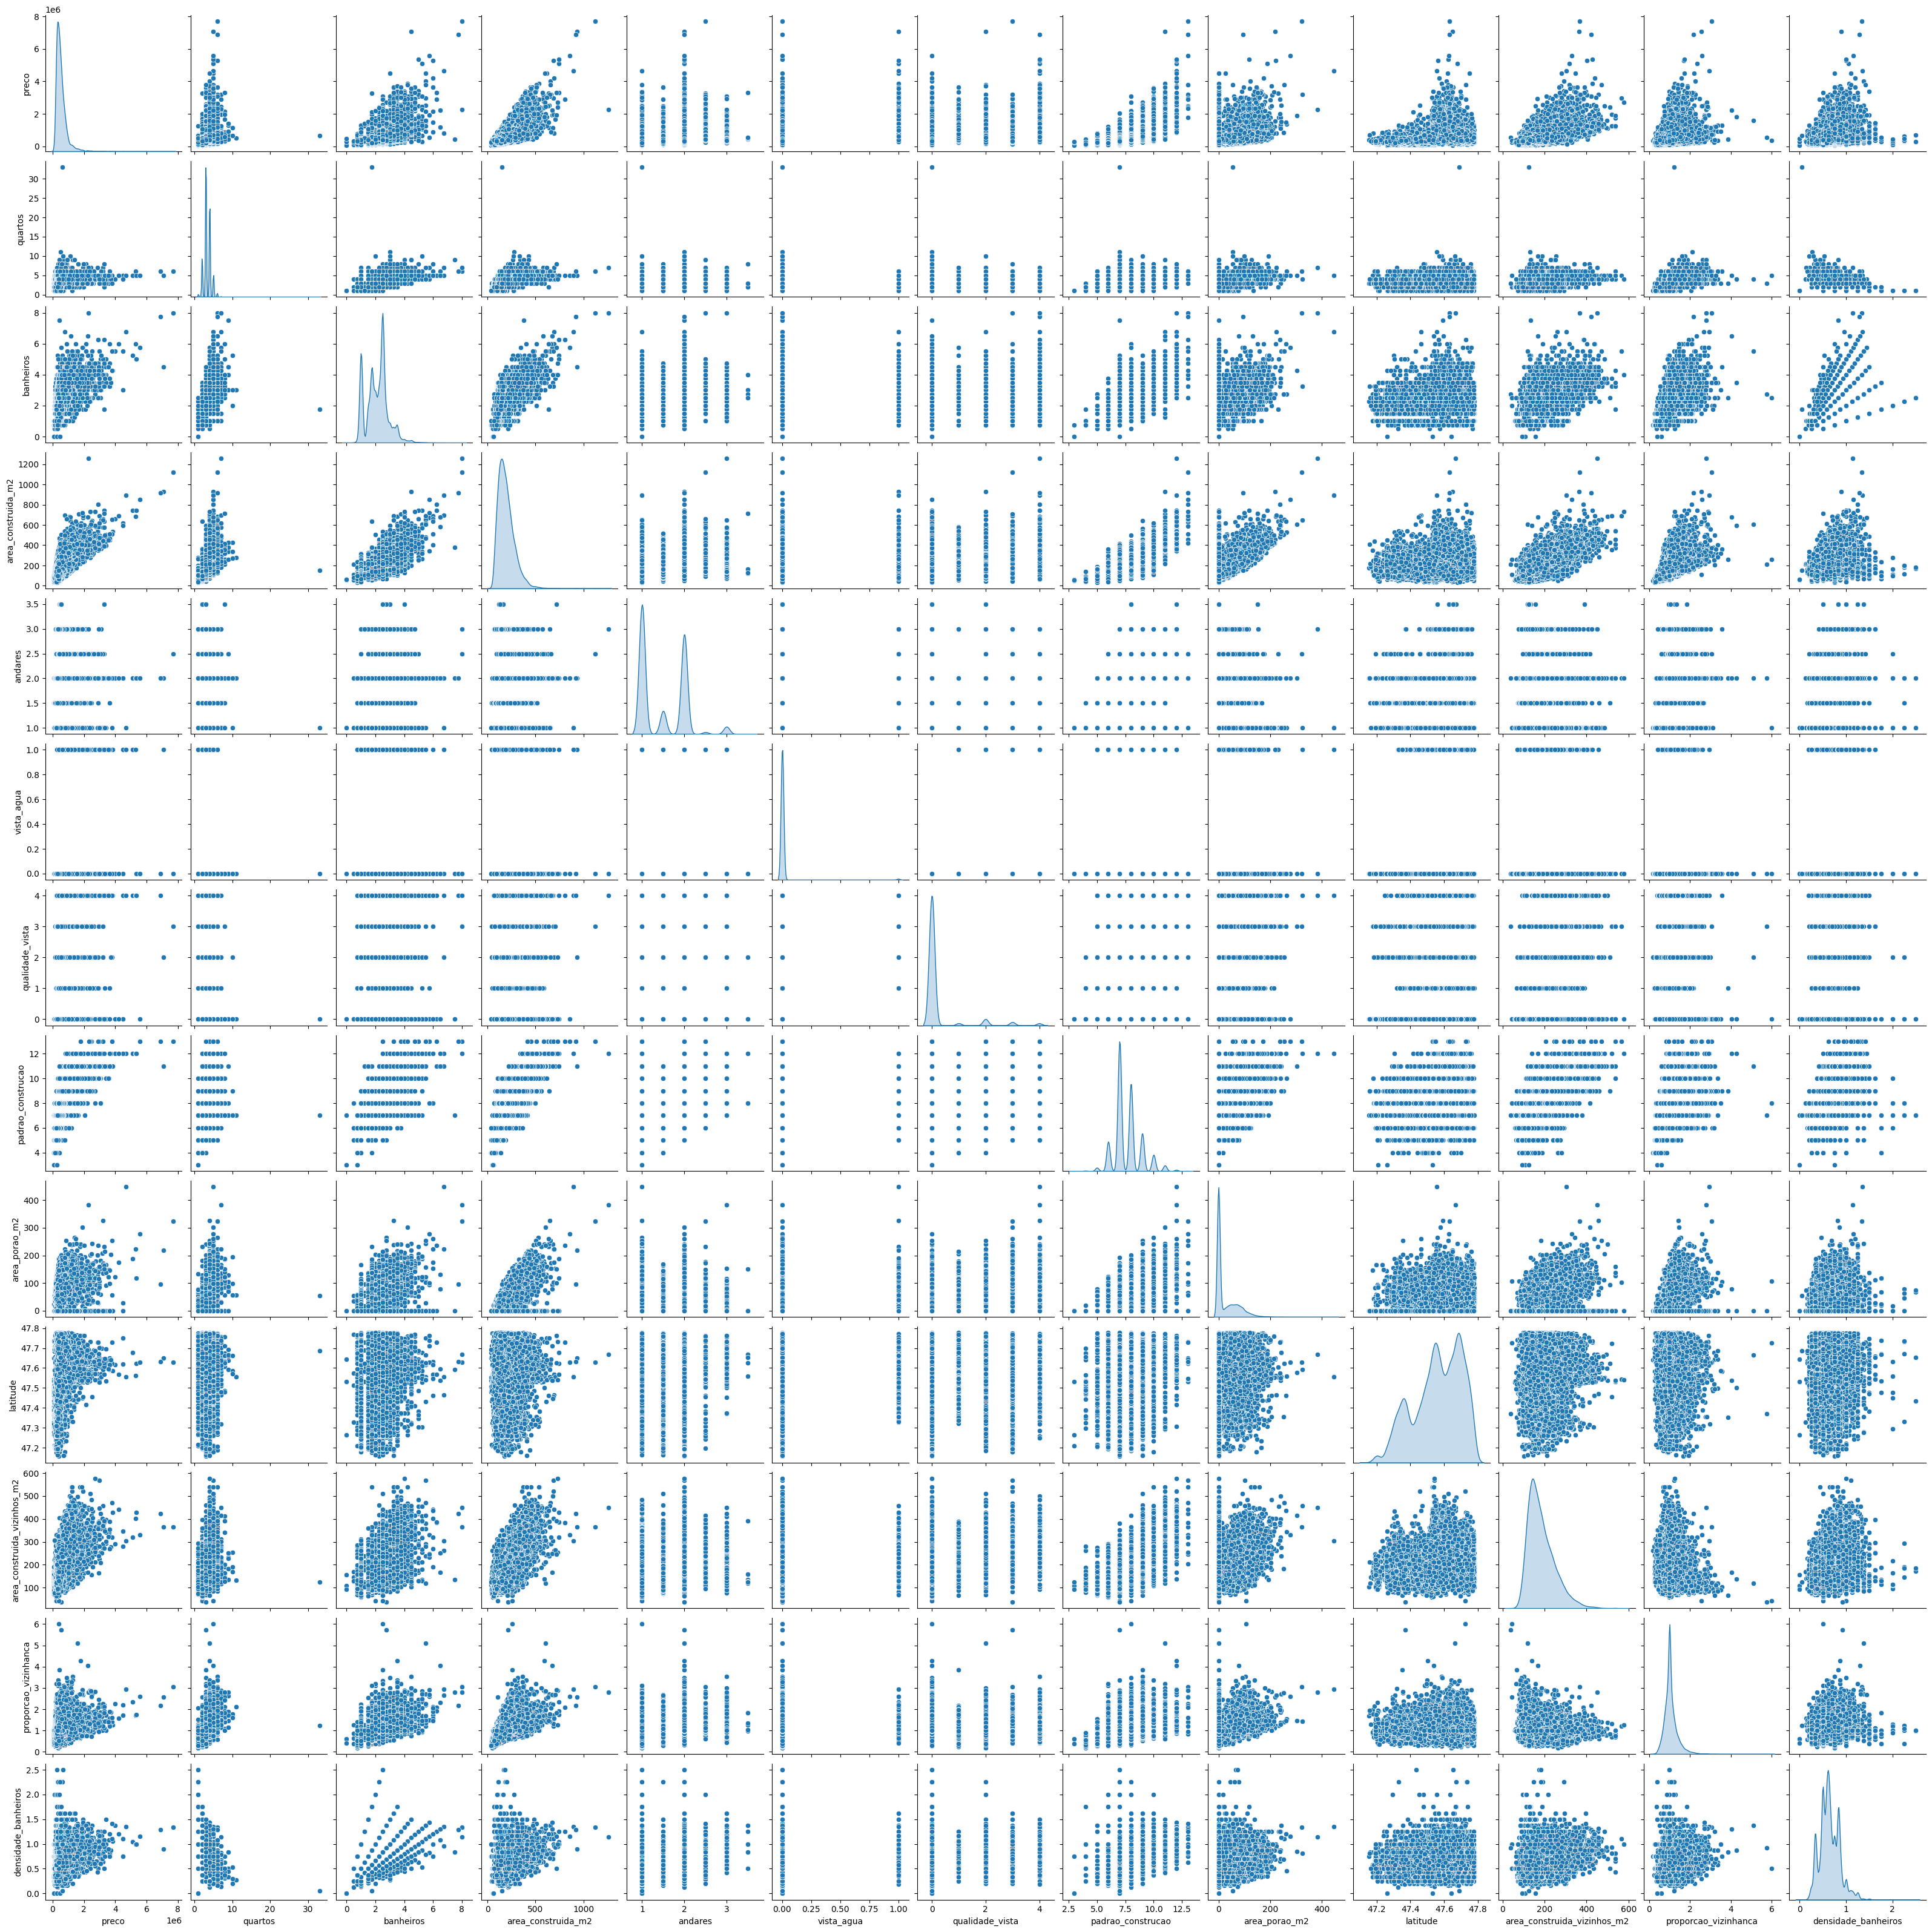

In [11]:
sns.pairplot(df_modelo, diag_kind='kde')
plt.show()

In [12]:
#x = df_modelo.drop(columns = 'preco')
#y = df_modelo['preco']
#x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 40)
#modelo = LinearRegression()
#modelo.fit(x_train, y_train)
#previsoes = modelo.predict(x_test)

In [13]:
#Uso o r2_score para analisar quao bem a minha regressão consegue explicar a variação dos dados
#r2 = r2_score(y_test, previsoes)
#mae = mean_absolute_error(y_test, previsoes)
#rmse = np.sqrt(mean_squared_error(y_test, previsoes))
 # calcula o módulo do erro e calcula-se a média(menos sensível a outliers)
#print(f'Erro médio absoluto: {mae:.2f}') # foca em erros médios típicos
# calcula o erro de cada previsão, eleva ao quadrado e calcula a média, após isso calcula a raiz desse resultado para voltarmos para a unidade de medida original(diferenciavel, facilita o ajuste de parametros, penaliza o modelo pelos outliers)
#print(f'Erro médio quadrático: {rmse:.2f}') # foca em erros grandes
#print(f"Acurácia: {r2:.2f}")

In [5]:
from sklearn.preprocessing import PolynomialFeatures
x = df_modelo.drop(columns = 'preco')
y = df_modelo['preco']
# usando degree = 2 para não aumentar muito a complexidade do modelo e assim ele decorar os dados, 
# bias = False pq a classe LinearRegression ja calcula o viés automaticamente
poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size = 0.2, random_state = 40)
modelo = LinearRegression()
modelo.fit(x_train, y_train)
previsoes = modelo.predict(x_test)
acuracia = r2_score(y_test, previsoes)
mae = mean_absolute_error(y_test, previsoes)
rmse = np.sqrt(mean_squared_error(y_test, previsoes))
 # calcula o módulo do erro e calcula-se a média(menos sensível a outliers)
print(f'Erro médio absoluto (MAE): {mae:.2f}')# foca em erros médios típicos
# calcula o erro de cada previsão, eleva ao quadrado e calcula a média, após isso calcula a raiz desse resultado para voltarmos para a unidade de medida original(diferenciavel, facilita o ajuste de parametros, penaliza o modelo pelos outliers)
print(f'Erro médio quadrático (RMSE): {rmse:.2f}')# foca em erros grandes
print(f"Acurácia (R²): {acuracia:.2%}")

Erro médio absoluto (MAE): 103698.84
Erro médio quadrático (RMSE): 163115.08
Acurácia (R²): 78.02%


In [15]:
#import plotly.graph_objects as go
#import numpy as np

# 1. Definir os limites para a linha de "Acerto Perfeito"
#min_val = min(y_test.min(), previsoes.min())
#max_val = max(y_test.max(), previsoes.max())

# 2. Criar a figura
#fig = go.Figure()

# 3. Adicionar os pontos (Scatter)
#fig.add_trace(go.Scatter(
 #   x=y_test, 
 #   y=previsoes,
 #   mode='markers',
 #   marker=dict(color='royalblue', opacity=0.5),
 #   name='Previsões do Modelo',
 #   hovertemplate='<b>Preço Real:</b> $%{x:,.2f}<br><b>Previsão:</b> $%{y:,.2f}<extra></extra>'
#))

# 4. Adicionar a linha de "Acerto Perfeito" (y = x)
#fig.add_trace(go.Scatter(
#    x=[min_val, max_val], 
#    y=[min_val, max_val],
#    mode='lines',
#    line=dict(color='tomato', dash='dash', width=3),
#    name='Acerto Perfeito (Real = Previsto)'
#))

# 5. Configurar o layout e formatação de eixos
#fig.update_layout(
#    title='<b>Avaliação do Modelo: Preço Real vs. Preço Previsto</b>',
#    xaxis_title='Preço Real do Imóvel ($)',
#    yaxis_title='Preço Previsto pelo Modelo ($)',
#    template='plotly_white',
#    width=900,
#    height=600,
#   legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
#)

# Formatação para aparecer em Milhões ou Milhares nos eixos
#fig.update_xaxes(tickformat="$.2s")
#fig.update_yaxes(tickformat="$.2s")

# Exibir o gráfico
#fig.show()

In [16]:
import plotly.graph_objects as go

# 1. Pegando os dados da Célula 4 (Polinomial)
# 'previsoes' já contém os resultados do modelo polinomial
limites_poly = [y_test.min(), y_test.max()]

# 2. Criar a figura
fig_poly = go.Figure()

# Pontos de previsão
fig_poly.add_trace(go.Scatter(
    x=y_test, y=previsoes,
    mode='markers',
    marker=dict(color='royalblue', opacity=0.5),
    name='Previsão Polinomial'
))

# Linha de Acerto Perfeito
fig_poly.add_trace(go.Scatter(
    x=limites_poly, y=limites_poly,
    mode='lines',
    line=dict(color='black', dash='dash'),
    name='Ideal'
))

fig_poly.update_layout(
    title=f'Regressão Polinomial)',
    xaxis_title='Preço Real',
    yaxis_title='Preço Previsto',
    template='plotly_white',
    width=700, height=500
)

fig_poly.update_xaxes(tickformat="$.2s")
fig_poly.update_yaxes(tickformat="$.2s")

fig_poly.show()

# Deploy


In [ ]:
#import joblib
# salva os pesos e os coeficientes do meu modelo em um formato binário(bytes) eficiente
#joblib.dump(modelo, 'modelo_previsao_casas.pkl')


In [ ]:
#import pandas as pd
#import joblib
#leio o arquivo binario gerado pelo dump e carrego os pesos de volta para a memória ram para usar meu modelo para fazer novas previsões
#modelo_carregado = joblib.load('modelo_previsao_casas.pkl')


#nova_casa = {
 #   'quartos': 3,
 #  'banheiros': 2.5,
  #  'area_construida_m2': 180,
   # 'andares': 2,
 #   'vista_agua': 0,
 #   'qualidade_vista': 0,
 #   'padrao_construcao': 7,
  #  'area_porao_m2': 0,
  #  'latitude': 47.5112,
  #  'area_construida_vizinhos_m2': 170,
  #  'preco_m2': 3200.50
#}

#Convertendo o meu dicionário para um dataframe
#df_input = pd.DataFrame([nova_casa])


# Fazer a previsão(aplica os valores que eu passei da nova_casa aos meus parâmetros, e assim, estima o preço da casa dados os meus parametros salvos e os dados de input), retorna uma lista com os valores de cada casa
#predicao = modelo_carregado.predict(df_input)

#predicao[0]


# resultado = prever_preco_imovel(nova_casa)
# print(f"O preço estimado para este imóvel é: ${resultado:,.2f}")

In [19]:
import joblib
# Salva o modelo (os pesos da regressão)
joblib.dump(modelo, 'modelo_polinomial.pkl')

# Salva o transformador (as regras para criar Area², Area*Quartos, etc.)
joblib.dump(poly, 'transformador_poly.pkl')

print("Modelo e Transformador salvos com sucesso!")

Modelo e Transformador salvos com sucesso!


In [18]:
df_modelo.tail()

,preco,quartos,banheiros,area_construida_m2,andares,vista_agua,qualidade_vista,padrao_construcao,area_porao_m2,latitude,area_construida_vizinhos_m2,proporcao_vizinhanca,densidade_banheiros
21595,360000.0,3,2.50,142.141789,3.0,0,0,8,0.0,47.6993,142.141789,1.000000,0.833333
21596,400000.0,4,2.50,214.606230,2.0,0,0,8,0.0,47.5107,170.012728,1.262295,0.625000
21597,402101.0,2,0.75,94.761193,2.0,0,0,7,0.0,47.5944,94.761193,1.000000,0.375000
21598,400000.0,3,2.50,148.645008,2.0,0,0,8,0.0,47.5345,130.993413,1.134752,0.833333
21599,325000.0,2,0.75,94.761193,2.0,0,0,7,0.0,47.5941,94.761193,1.000000,0.375000


In [22]:
import pandas as pd
import joblib

# 1. Carrega os arquivos binários de volta para a memória
modelo_carregado = joblib.load('modelo_polinomial.pkl')
poly_carregado = joblib.load('transformador_poly.pkl')

# 2. Dados da nova casa (exatamente como no seu dataframe original)
nova_casa = {
    'quartos': 3,
    'banheiros': 2.5,
    'area_construida_m2': 180,
    'andares': 2,
    'vista_agua': 0,
    'qualidade_vista': 0,
    'padrao_construcao': 7,
    'area_porao_m2': 0,
    'latitude': 47.5112,
    'area_construida_vizinhos_m2': 170,
    'proporcao_vizinhanca': 1,
    'densidade_banheiros': 0.80

}

# 3. Convertendo para DataFrame
df_input = pd.DataFrame([nova_casa])

# --- O PASSO MAIS IMPORTANTE ---
# Transforma as 11 colunas originais em colunas polinomiais (ex: cria os quadrados e interações)
# O modelo só aceita os dados se eles passarem por aqui primeiro
df_input_poly = poly_carregado.transform(df_input)

# 4. Fazer a previsão usando os dados transformados
predicao = modelo_carregado.predict(df_input_poly)

print(f"O preço estimado para este imóvel é: ${predicao[0]:,.2f}")

O preço estimado para este imóvel é: $1,120,926.18
